In [1]:
from helpers.predictors import *

show = True

#resolution = (3840, 2160)
resolution = (1920, 1080)

video_name = 'gopro1_selected_hands_2'

in_file = f'inputs/{video_name}.MP4'
video_dir = f'inputs/{video_name}'
output_file = f'vis_dir/{video_name}'
exclude_box = None #[[610, 80, 795, 185]]
curr_obj_id = 0

Device: cuda
Torch compile enabled: True
Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth
Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Disable torch compile due to unsupported GPU.

Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=pkg://sam2
	provider=schema, path=structured://
Falling back to SAM tracking only


In [ ]:
bboxes_rtm, frame_idx_rtm = detect_bbox(in_file, show=show)
bboxes_rtm, frame_idx_rtm

inputs/gopro1_selected.MP4
Hand bbox detected
[ 995.1108   132.77896 1206.324    256.0908 ]
End of video


(array([[ 995.1108 ,  132.77896, 1206.324  ,  256.0908 ]], dtype=float32), 1)

In [6]:
bboxes_yolo, frame_idx_yolo = detect_bbox_yolo(in_file, exclude_box, write_folder=True, show=show)
bboxes_yolo, frame_idx_yolo

inputs/gopro1_selected.MP4
Frame 0 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00000.jpg
Frame 1 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00001.jpg
Frame 2 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00002.jpg
Frame 3 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00003.jpg
Frame 4 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00004.jpg
Frame 5 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00005.jpg
Frame 6 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00006.jpg
Frame 7 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPose\inputs\gopro1_selected\00007.jpg
Frame 8 has been extracted and saved as c:\Users\aelvy\Documents\GitHub\ORPos

KeyboardInterrupt: 

In [11]:
bboxes_in = bboxes_yolo
frame_idx = frame_idx_yolo
bboxes_in, frame_idx

(array([[1902,  671, 2008,  789]]), 181)

In [ ]:
initialize_tracking_model(True)

frame loading (JPEG): 100%|██████████| 300/300 [00:31<00:00,  9.52it/s]
C:\Users\aelvy\Documents\GitHub\sam2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\aelvy\Documents\GitHub\sam2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


0


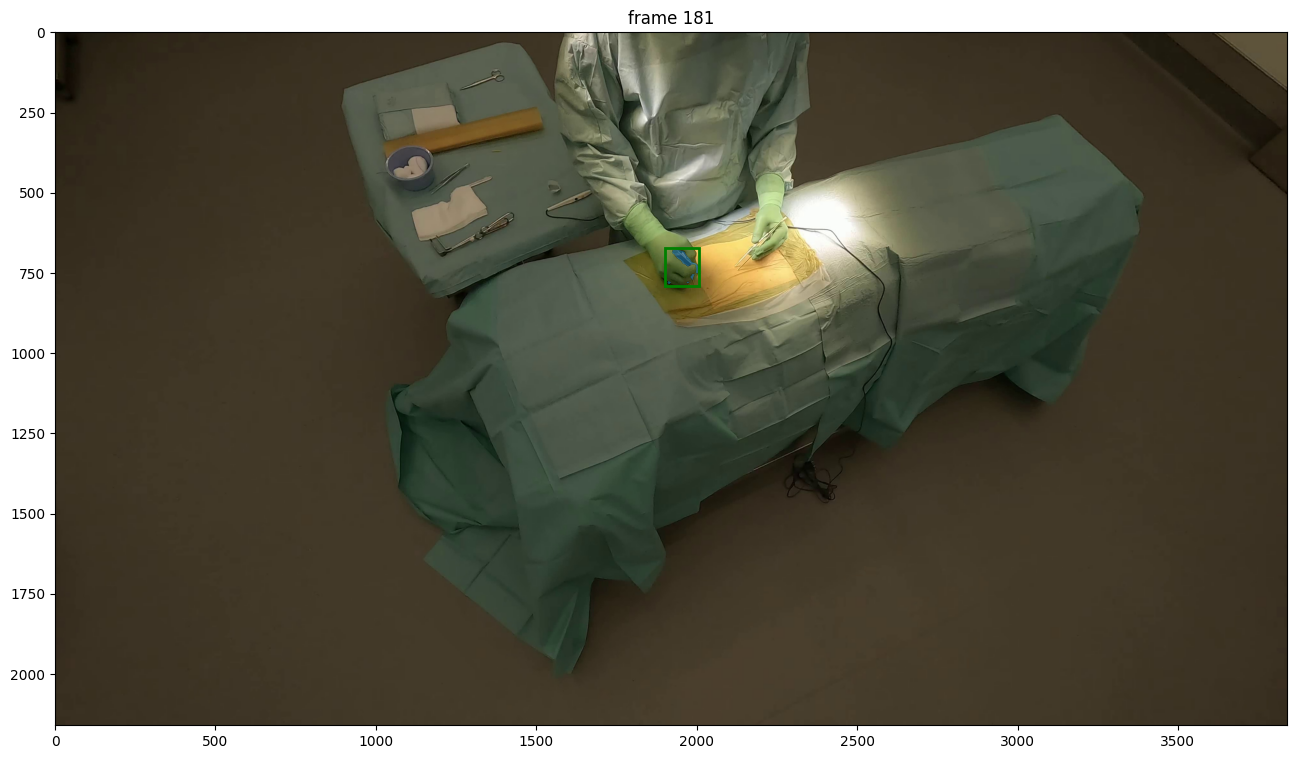

In [12]:
inference_state, predictor, frame_names = add_obj_to_sam(video_dir, bboxes_in[0], frame_idx, curr_obj_id, show=show)

In [13]:
video_segments, bboxes = track_with_sam(video_dir, inference_state, predictor, frame_names, show=show)

propagate in video:   3%|▎         | 6/182 [00:56<27:46,  9.47s/it]


KeyboardInterrupt: 

In [7]:
render_bbox_video(output_file, video_dir, bboxes, frame_names)

100%|██████████| 751/751 [03:02<00:00,  4.11it/s]


In [7]:
bboxes_yolo, frame_idx = detect_bbox_yolo(in_file, exclude_box, bboxes, write_folder=True, show=show)

inputs/gopro2_selected_hands_2.mp4
hand with 0.85 confidence


In [8]:
curr_obj_id = 1
curr_obj_id

1

frame loading (JPEG): 100%|██████████| 751/751 [00:49<00:00, 15.17it/s]


1


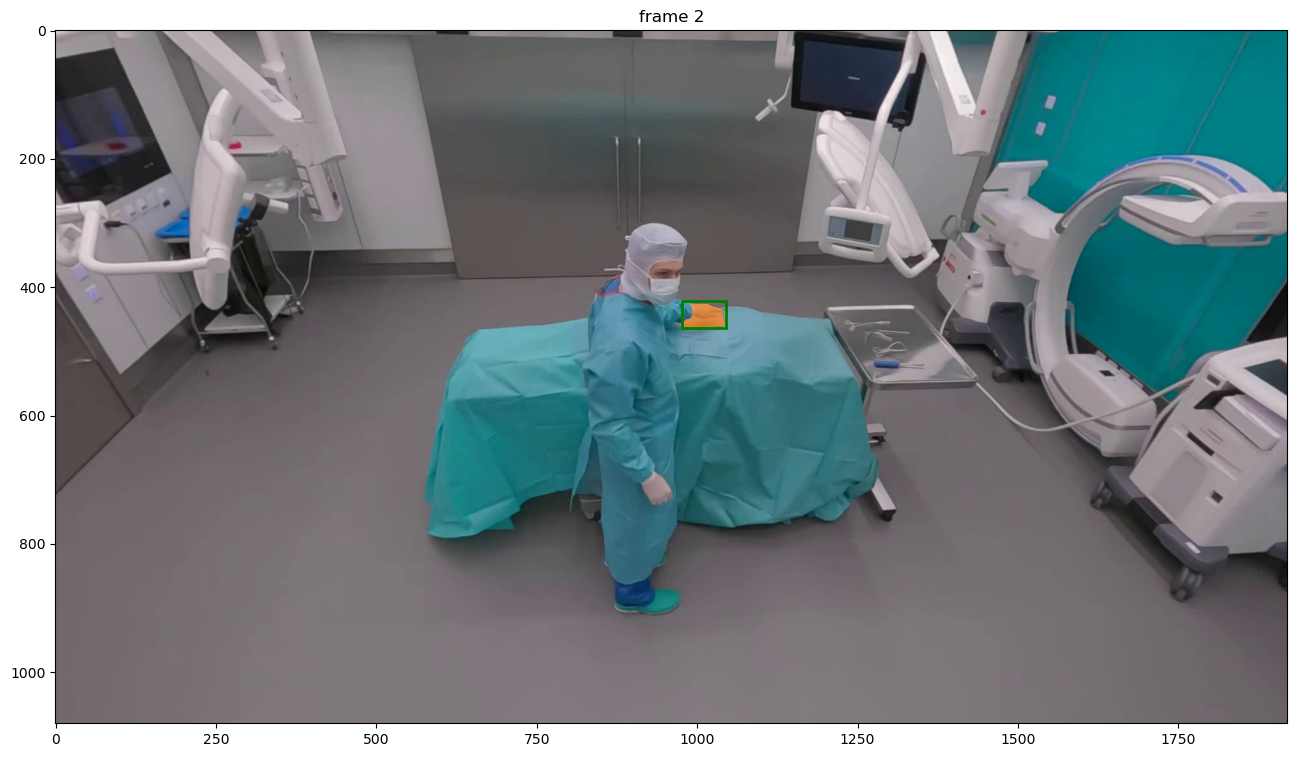

In [9]:
inference_state, predictor, frame_names = add_obj_to_sam(video_dir, bboxes_yolo[0], frame_idx, curr_obj_id, show=show)

In [10]:
prev_bboxes = bboxes

In [11]:
video_segments, bboxes = track_with_sam(video_dir, inference_state, predictor, frame_names, show=show, prev_bboxes=prev_bboxes)

propagate in video:   0%|          | 0/749 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 3/3 [00:11<00:00,  3.70s/it]


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [ ]:
render_bbox_video(output_file, video_dir, bboxes, frame_names)

100%|██████████| 751/751 [03:09<00:00,  3.97it/s]


In [12]:
import pickle

In [13]:
with open(f'bboxes/tracked_bboxes_{video_name}.pkl', 'wb+') as f:
    pickle.dump(bboxes, f)

In [14]:
for k, v in bboxes.items():
    v_new = {}
    for k2, v2 in v.items():
        if len(v2) > 0:
            v_new[k2] = v2
    bboxes[k] = v_new

In [15]:
bboxes

{0: {0: array([[913, 688, 964, 740]], dtype=int64),
  1: array([[ 974,  426, 1046,  465]], dtype=int64)},
 1: {0: array([[913, 689, 963, 741]], dtype=int64),
  1: array([[ 975,  426, 1046,  466]], dtype=int64)},
 2: {0: array([[913, 689, 963, 741]], dtype=int64),
  1: array([[ 977,  426, 1045,  465]], dtype=int64)},
 3: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  427, 1045,  466]], dtype=int64)},
 4: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  427, 1045,  466]], dtype=int64)},
 5: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  426, 1046,  466]], dtype=int64)},
 6: {0: array([[913, 688, 962, 741]], dtype=int64),
  1: array([[ 976,  426, 1046,  466]], dtype=int64)},
 7: {0: array([[913, 688, 962, 741]], dtype=int64),
  1: array([[ 976,  425, 1046,  466]], dtype=int64)},
 8: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 976,  423, 1046,  466]], dtype=int64)},
 9: {0: array([[913, 688, 962, 741]], dtype=in